<a href="https://colab.research.google.com/github/aruniitr-25/perceptron/blob/main/feature_scaling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

FEATURE SCALING:

In [31]:
import numpy as np
import pandas as pd

In [32]:
df = pd.read_csv('/content/drive/MyDrive/historical_data.csv')

In [33]:
df = df.iloc[:,2:]
df.head()

,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [34]:
import seaborn as sns

<Axes: xlabel='Execution Price', ylabel='Size Tokens'>

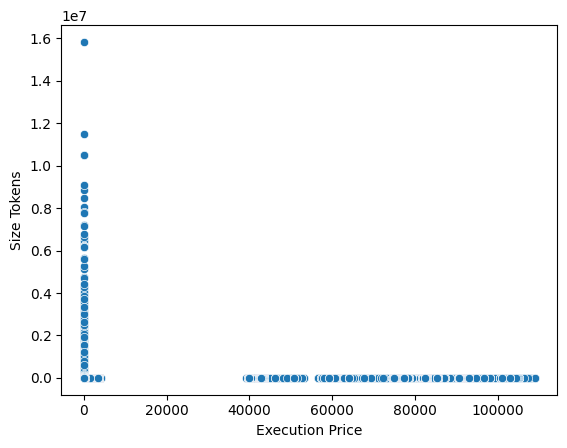

In [36]:
sns.scatterplot(x=df.iloc[:,0], y=df.iloc[:,1])

In [54]:
X = df.iloc[:,0:2]
y = df['Side'].map({'BUY': 1, 'SELL': 0})

In [38]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [39]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [40]:
model = Sequential()

model.add(Dense(128,activation='relu',input_dim=2))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [42]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 513 (2.00 KB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [55]:
history = model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=10)

Epoch 1/10
5281/5281 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan
Epoch 2/10
5281/5281 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan
Epoch 3/10
5281/5281 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan
Epoch 4/10
5281/5281 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan
Epoch 5/10
5281/5281 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan
Epoch 6/10
5281/5281 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan
Epoch 7/10
5281/5281 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan
Epoch 8/10
5281/5281 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.

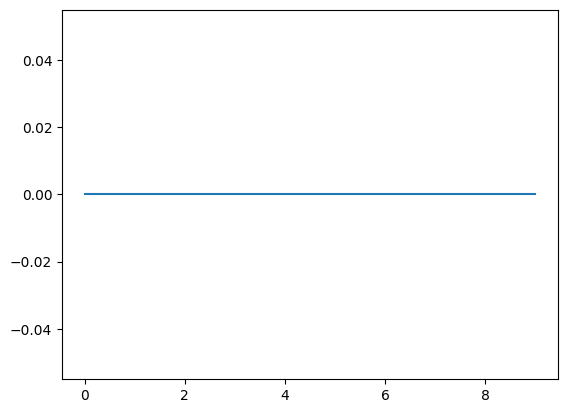

In [48]:
import matplotlib.pyplot as plt
plt.plot(history.history['val_accuracy'])

Applying Scaling

In [56]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [49]:
X_train_scaled

array([[ 2.42412377, -0.04410672],
       [-0.38809316, -0.01482923],
       [-0.38805743, -0.00971847],
       ...,
       [-0.38806729, -0.030133  ],
       [-0.38793092, -0.0440755 ],
       [-0.38808048, -0.03305887]])

<Axes: >

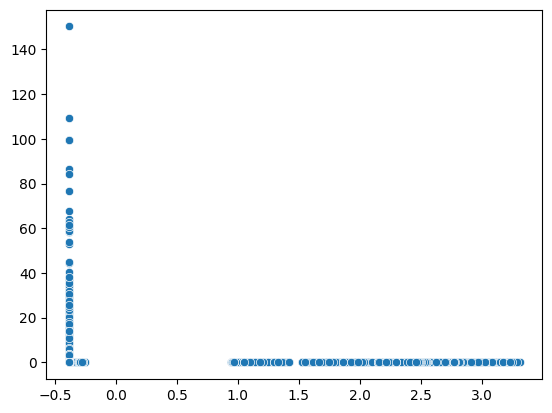

In [51]:
sns.scatterplot(x=X_train_scaled[:,0], y=X_train_scaled[:,1])

In [57]:
model = Sequential()

model.add(Dense(128,activation='relu',input_dim=2))
model.add(Dense(1,activation='sigmoid'))

model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

history = model.fit(X_train_scaled,y_train,validation_data=(X_test_scaled,y_test),epochs=10)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5281/5281 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.0000e+00 - loss: -3132352666533888.0000 - val_accuracy: 0.0000e+00 - val_loss: -8717604105486336.0000
Epoch 2/10
5281/5281 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.0000e+00 - loss: -18084277627387904.0000 - val_accuracy: 0.0000e+00 - val_loss: -29225405613342720.0000
Epoch 3/10
5281/5281 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - accuracy: 0.0000e+00 - loss: -43764617234612224.0000 - val_accuracy: 0.0000e+00 - val_loss: -60059405328056320.0000
Epoch 4/10
5281/5281 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.0000e+00 - loss: -79630162546655232.0000 - val_accuracy: 0.0000e+00 - val_loss: -100973950984519680.0000
Epoch 5/10
5281/5281 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.0000e+00 - loss: -125537899742494720.0000 - val_accuracy: 0.0000e+00 - val_loss: -151900864271876096.0000
Epoch 6/10
5281/5281 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.0000e+00 - loss: -181401225101574144.0000 - val_accuracy: 0.0000e+00 - val_l

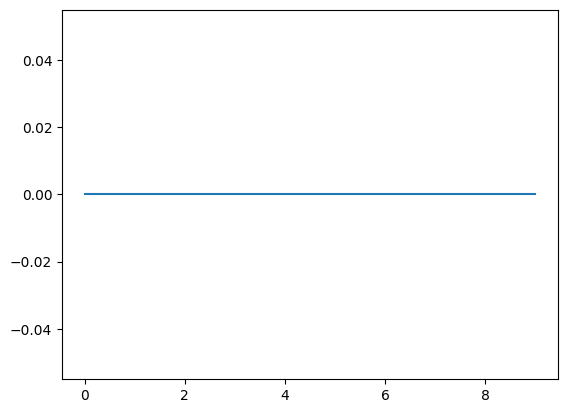

In [58]:
import matplotlib.pyplot as plt
plt.plot(history.history['val_accuracy'])